In [1]:
import numpy as np
import pandas as pd
from scipy import stats

import os 
import sys
sys.path.append("..//utils/")

import color_utils, helpers
from load_matlab_data import loadmat_sbx
from load_matlab_data import loadmat_v73

from scipy.io import loadmat
sys.path.append("..//neural/")
from format_waveform_data import get_spike_times, load_wf_data, sort_wf_by_channel, pop_normalize
import process_SC_data
from format_behavior_data import load_behavior_data, get_feeder_ints, get_feeder_periods, classify_feeder_ints

import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

In [2]:
''' File Paths '''
root_dir = "Z:/Isabel/data/Grid Caching Data/"
save_figs_dir = f"../figures/basic_neural_analysis_sc/"
if os.path.isdir(save_figs_dir):
    print('save directory exists')
else:
    os.mkdir(save_figs_dir)

''' Bird and session list '''
data_dict = {}

all_dirs = sorted(os.listdir(root_dir))
ignore_files = ['arena_im_1_1.mat', '.DS_Store']
session_dirs = []
for s_dir in all_dirs:
    if s_dir in ignore_files:
        continue
    elif '_' in s_dir:
        session_dirs.append(s_dir)

save directory exists


In [3]:
bird_ids = []
for session_folder in session_dirs:
    parts = session_folder.split('_')
    bird = parts[0]
    session_id = f'{parts[1]}_{parts[2]}'
    if bird in bird_ids:
        data_dict[bird][session_id] = {}
    else:
        data_dict[bird] = {}
        data_dict[bird][session_id] = {}
    bird_ids.append(bird)

In [14]:
bird = 'AMB43'
session_id = '221027_104018'
data_dir = f"{root_dir}/{bird}_{session_id}/"

In [5]:
''' Load the aligned neural data'''
dt = 1/60
spike_fr, excitatory_idx, inhibitory_idx = process_SC_data.load_neural_data(data_dir)
n_cells, n_frames = spike_fr.shape
norm_fr = pop_normalize(spike_fr, dt=dt)

In [25]:
# feeder visit time windows
t_pre_sec = 1
t_begin_sec = 0.5
t_end_sec = 0.5
t_post_sec = 1

In [26]:
''' Load and format behavior data '''
seed_struct, count_data = load_behavior_data(data_dir)

# get the feeder interactions + classify as open/closed
feeder_int_start, feeder_int_end, feeder_idx = get_feeder_ints(count_data, use_beak=False)
n_feeder_int = feeder_int_start.shape[0]

# convert feeder time windows to frames
t_pre = int(t_pre_sec/dt)
t_begin = int(t_begin_sec/dt)
t_end = int(t_end_sec/dt)
t_post = int(t_post_sec/dt)
n_timepoints = t_pre + t_begin + t_end + t_post

Z:/Isabel/data/Grid Caching Data//AMB43_221027_104018/annotatedSeeds.mat


In [28]:
t_begin + t_end

60

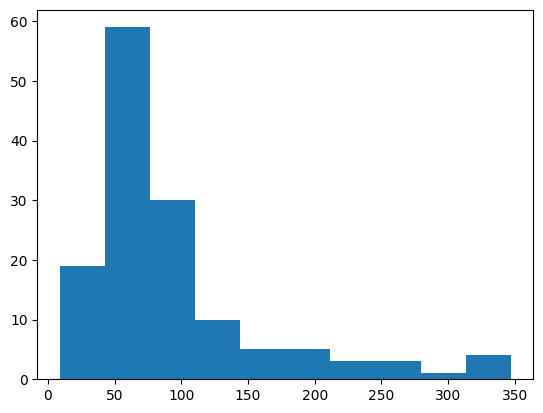

In [8]:
feeder_dur = feeder_int_end-feeder_int_start

plt.hist(feeder_dur[feeder_dur<400])
plt.show()

In [48]:
''' Activity of all cells relative to onset/ offset of feeder interactions '''
# responses for each interaction
all_feeder_responses = np.zeros((n_feeder_int, n_cells, n_timepoints))
for i, (feeder_on, feeder_off) in enumerate(zip(feeder_int_start, feeder_int_end)):
    if (feeder_on-t_pre < 0) | (feeder_off+t_post > n_frames):
        continue
    if feeder_off - feeder_on < t_begin+t_end:
        continue
    this_feeder_start = norm_fr[:, feeder_on-t_pre:feeder_on+t_begin]
    this_feeder_end = norm_fr[:, feeder_off-t_end:feeder_off+t_post]
    all_feeder_responses[i] = np.column_stack([this_feeder_start, this_feeder_end])
rows_to_keep = np.abs(np.sum(all_feeder_responses, axis=(1, 2))).astype(bool)
# all_feeder_responses = all_feeder_responses[rows_to_keep]

# average response across interactions
avg_feeder_responses = np.mean(all_feeder_responses, axis=0)
smooth_feeder_responses = gaussian_filter1d(avg_feeder_responses, 5, axis=1, mode='nearest')  

In [50]:
rows_to_keep.shape

(140,)

In [49]:
all_feeder_responses.shape

(140, 39, 180)

In [33]:
onset_window = {}
onset_window[bird] = np.asarray([10, 15])
offset_window = {}
offset_window[bird] = np.asarray([10, 15])

In [34]:
# average response binned by arrival/during/departure
arrive_pad = onset_window[bird]
arrive_t = t_pre
depart_pad = offset_window[bird]
depart_t = t_pre + t_begin + t_end
arrive_response = np.sum(avg_feeder_responses[:, arrive_t-arrive_pad[0]:arrive_t+arrive_pad[1]], axis=1)/np.sum(arrive_pad)
during_response = np.sum(avg_feeder_responses[:, arrive_t+arrive_pad[1]:depart_t-depart_pad[0]],  axis=1)/((t_begin+t_end) - (arrive_pad[1]+depart_pad[0]))
depart_response = np.sum(avg_feeder_responses[:, depart_t-depart_pad[0]:depart_t+depart_pad[1]],  axis=1)/np.sum(depart_pad)

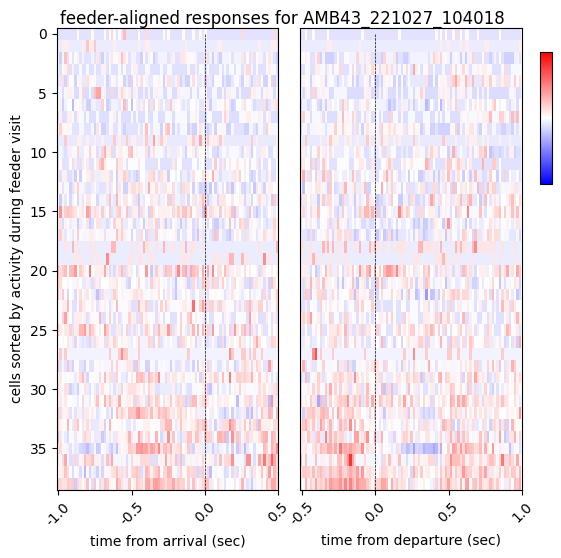

In [47]:
''' Plot average responses for all cells '''
sort_idx = np.argsort(during_response)  
assert sort_idx.shape[0] == avg_feeder_responses.shape[0]

# plot responses relative to onset/offset
gs_kw = dict(wspace=0.1)
f, ax = plt.subplots(1, 2, figsize=(6, 6), gridspec_kw=gs_kw)
im0 = ax[0].imshow(avg_feeder_responses[sort_idx, :n_timepoints//2], clim=[-1, 1], 
                    aspect='auto', cmap='bwr', interpolation='none')
im1 = ax[1].imshow(avg_feeder_responses[sort_idx, n_timepoints//2:], clim=[-1, 1], 
                    aspect='auto', cmap='bwr', interpolation='none')
ylims = ax[0].get_ylim()

# plot arrival/departure
ax[0].vlines(t_pre, 0, n_cells, colors='k', linestyles='dashed', lw=0.5)
ax[1].vlines(t_end, 0, n_cells, colors='k', linestyles='dashed', lw=0.5)
ax[0].set_ylim(ylims)
ax[1].set_ylim(ylims)

# axis labels
ax[0].set_xlabel('time from arrival (sec)')
ax[1].set_xlabel('time from departure (sec)')
ax[0].set_ylabel('cells sorted by activity during feeder visit')
ax[1].set_yticks([])
ax[1].tick_params(labelleft=False)
f.suptitle(f'feeder-aligned responses for {bird}_{session_id}', y=0.91)

# ticks
ax[0].set_xticks(np.arange(0, t_pre+t_begin+1/dt/2, 1/dt/2))
ax[1].set_xticks(np.arange(0, t_post+t_end+1/dt/2, 1/dt/2))
ax0_labels = (np.arange(-t_pre, t_begin+1/dt/2, 1/dt/2))*dt
ax1_labels = (np.arange(-t_end, t_post+1/dt/2, 1/dt/2))*dt
ax[0].set_xticklabels(ax0_labels)
ax[1].set_xticklabels(ax1_labels)

# add a colorbar
cax = f.add_axes([0.93, 0.62, 0.02, 0.22]) # [left, bottom, width, height]
cbar = f.colorbar(im1, cax=cax, orientation='vertical')
# cbar.set_label('activity (z-score)', fontsize=tick_label)
cbar.set_ticks([])
# cbar.ax.text(0.5, -0.05, '-1 std', transform=cbar.ax.transAxes,
#                 ha='center', va='top', fontsize=tick_label)
# cbar.ax.text(0.5, 1.02, '1 std', transform=cbar.ax.transAxes,
#                 ha='center', va='bottom', fontsize=tick_label)

plt.show()

In [43]:
np.arange(0, t_pre+t_begin+1/dt/2, 1/dt/2)

array([ 0., 30., 60., 90.])

In [41]:
t_pre+t_begin

90

In [12]:
bird_ids = []
for session_folder in session_dirs:
    parts = session_folder.split('_')
    bird = parts[0]
    session_id = f'{parts[1]}_{parts[2]}'
    if bird in bird_ids:
        data_dict[bird][session_id] = {}
    else:
        data_dict[bird] = {}
        data_dict[bird][session_id] = {}
        bird_ids.append(bird)

In [13]:
bird_ids

['AMB43', 'IND106', 'LMN169', 'SLV143', 'TRQ70']

In [2]:
''' File Paths '''
root_dir = "Z:/Isabel/data/hpc_implants/"
save_figs_dir = f"../figures/basic_neural_analysis/"
data_file = f"{root_dir}stim_session_data.npy"
session_info_file = f"{root_dir}good_sessions.xlsx"

In [3]:
feeder_info = pd.read_excel(session_info_file, sheet_name='Feeder Coding', header=0)
feeder_coding_dict = {}
for i, row in feeder_info.iterrows():
    # get the bird and session IDs
    bird = row['bird']
    session_id = str(row['session'])
    if bird not in feeder_coding_dict.keys():
        feeder_coding_dict[bird] = {}
    feeder_coding_dict[bird][session_id] = {}
    
    # get the cell IDs associated with each feeder response
    for col in feeder_info.columns:
        if col in ['bird', 'session']:
            continue
        feeder_cell_string = row[col]

        if pd.isna(feeder_cell_string): # handle empty cells
            feeder_coding_dict[bird][session_id][col] = np.array([])
        else:
            feeder_cells = np.array([int(x.strip()) for x in str(feeder_cell_string).split(',')])
            feeder_coding_dict[bird][session_id][col] = feeder_cells

In [4]:
''' Data params '''
bird = 'LMN146' # update as needed
data_dict = np.load(data_file, allow_pickle=True).item()
session_list = data_dict[bird]['all_sessions']

# collect sessions with pose tracking & ephys
behavior_sessions = []
for session_id in session_list:
    preprocessed_data = data_dict[bird][session_id]['preprocessed_data']
    if ('behavior' in preprocessed_data) & ('ephys' in preprocessed_data):
        behavior_sessions.append(session_id)

In [5]:
behavior_sessions

['251107', '251110', '251112', '251114', '251117', '251119', '251121']

In [6]:
session_id = '251114'

In [7]:
''' Get the file params '''
session_dir = f"{root_dir}{bird}/{bird}_{session_id}/"
data_dir = f"{session_dir}/behavior_data/"
pred_date = data_dict[bird][session_id]['pred_date']
ephys_id = data_dict[bird][session_id]['ephys_id']
ephys_folder= f"{root_dir}{bird}/{bird}_{session_id}/{bird}_{ephys_id}/"
for folder in sorted(os.listdir(ephys_folder)):
    if 'kilosort4' in folder:
        for file in sorted(os.listdir(f"{ephys_folder}{folder}")):
            if 'waveformStruct' in file:
                ks_dir = f"{bird}_{ephys_id}/{folder}/"

In [8]:
stim_idx_ch = data_dict[bird][session_id]['worm_ch_idx']

In [9]:
cell_pos.shape[0]

NameError: name 'cell_pos' is not defined

In [10]:
# get the stim channel positions
ch_pos = data_dict[bird][session_id]['channel_pos']
stim_pos = ch_pos[stim_idx_ch.astype(bool)]

# match each cell to its channel position
cell_pos = data_dict[bird][session_id]['cell_pos']
n_cells = cell_pos.shape[0]
stim_idx_cell = np.zeros(n_cells).astype(bool)
for cell_idx, this_pos in enumerate(cell_pos):
    stim_idx_cell[cell_idx] = np.any(np.all(stim_pos==this_pos, axis=1))

In [11]:
ch_pos

array([[      nan, 3325.8828,       nan],
       [      nan, 3325.8828,       nan],
       [      nan, 3307.3828,       nan],
       [      nan, 3344.3828,       nan],
       [      nan, 3325.8828,       nan],
       [      nan, 3307.3828,       nan],
       [      nan, 3344.3828,       nan],
       [      nan, 3325.8828,       nan],
       [      nan, 3307.3828,       nan],
       [      nan, 3344.3828,       nan],
       [      nan, 3325.8828,       nan],
       [      nan, 3307.3828,       nan],
       [      nan, 3344.3828,       nan],
       [      nan, 3325.8828,       nan],
       [      nan, 3307.3828,       nan],
       [      nan, 3344.3828,       nan],
       [      nan, 3325.8828,       nan],
       [      nan, 3307.3828,       nan],
       [      nan, 3344.3828,       nan],
       [      nan, 3325.8828,       nan],
       [      nan, 3307.3828,       nan],
       [      nan, 3344.3828,       nan],
       [      nan, 3325.8828,       nan],
       [      nan, 3307.3828,     

In [10]:
# get the channel indices for each cell
ephys_dir = f"{session_dir}{bird}_{ephys_id}/raw_ephys_output/"
waveform_struct = load_wf_data(session_dir, ks_dir=ks_dir)
_, wf_channels, _, ch_names = sort_wf_by_channel('', waveform_struct,
                                                                        data_dir=ephys_dir,
                                                                        return_ch_names=True)       
wf_ch_idx = np.asarray([ch_names.index(ch) for ch in wf_channels])

Z:/Isabel/data/hpc_implants/LMN146/LMN146_251114/LMN146_251114_113204/kilosort4_blanked/waveformStruct.mat
Z:/Isabel/data/hpc_implants/LMN146/LMN146_251114/LMN146_251114_113204/raw_ephys_output/intan_info.mat


In [11]:
permissive = True
if permissive:
    n_channels = stim_idx_ch.shape[0]
    shank_idx = n_channels//2
    stim_idx_ch_adj = np.zeros(n_channels).astype(bool)
    for ch in range(n_channels):
        if stim_idx_ch[ch]:
            stim_idx_ch_adj[ch] = True
            continue
        elif ch < shank_idx:
            dorsal_resp = np.any(stim_idx_ch[:ch])
            ventral_resp = np.any(stim_idx_ch[ch+1:shank_idx])
        elif ch >= shank_idx:
            dorsal_resp = np.any(stim_idx_ch[shank_idx:ch])
            ventral_resp = np.any(stim_idx_ch[ch+1:])                   
        if dorsal_resp & ventral_resp:
            stim_idx_ch_adj[ch] = True

In [12]:
stim_idx_ch

array([ True, False, False, False, False, False, False, False, False,
       False, False,  True, False,  True,  True,  True,  True, False,
       False, False, False,  True,  True, False,  True,  True, False,
        True, False, False, False, False, False, False,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True, False, False,  True, False, False,  True,
       False, False,  True,  True,  True,  True,  True, False, False,
       False])

In [13]:
stim_idx_ch_adj

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False, False, False, False, False, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
       False])

In [14]:
# determine if there's a stim response on each cell's channel
n_cells = wf_ch_idx.shape[0]
stim_idx_cell = np.zeros(n_cells).astype(bool)
for cell_idx, ch_idx in enumerate(wf_ch_idx):
    stim_idx_cell[cell_idx] = stim_idx_ch[ch_idx]

In [16]:
np.sum(stim_idx_cell)

43

In [13]:
session_id = '251008'
save_figs = f"{save_figs_dir}{bird}/feeder_responses/"
if os.path.isdir(save_figs):
    print('save directory exists')
else:
    os.mkdir(save_figs)

save directory exists


In [14]:
''' Plot feeder responses for each session '''
print(f'plotting feeder responsive cells for {bird}_{session_id}')
feeder_exclude = 0

''' Get the file params '''
session_dir = f"{root_dir}{bird}/{bird}_{session_id}/"
data_dir = f"{session_dir}/behavior_data/"
pred_date = data_dict[bird][session_id]['pred_date']
ephys_id = data_dict[bird][session_id]['ephys_id']
ephys_folder= f"{root_dir}{bird}/{bird}_{session_id}/{bird}_{ephys_id}/"
for folder in sorted(os.listdir(ephys_folder)):
    if 'kilosort4' in folder:
        for file in sorted(os.listdir(f"{ephys_folder}{folder}")):
            if 'waveformStruct' in file:
                ks_dir = f"{bird}_{ephys_id}/{folder}/"

plotting feeder responsive cells for IND67_251008


In [15]:
''' Load the frame times '''
sampling_rate = 30000 # intan
framet_raw = np.load(f'{data_dir}frame_times.npy')
framet_raw = np.squeeze(framet_raw)
dt = np.unique(np.round(np.diff(framet_raw), 2))
dt = dt[0]

# align so that 0 is the video start time
start_t = framet_raw[0]
frame_t = framet_raw - start_t
frame_samples = np.append(frame_t, frame_t[-1] + dt)*sampling_rate
n_frames = frame_t.shape[0]

''' Load/format the neural data '''
# get the cell IDs and raw spike times
good_clusters, spike_id, spike_samp_raw = get_spike_times(session_dir, ks_dir=ks_dir)
n_cells = good_clusters.shape[0]

# keep only spikes from within the session
spike_t = spike_samp_raw - start_t*sampling_rate
spike_id = spike_id[(spike_t >= 0) & (spike_t <= frame_samples[-1])]
spike_t = spike_t[(spike_t >= 0) & (spike_t <= frame_samples[-1])]

# spikes per frame and spike bool
spike_fr = np.zeros((n_cells, n_frames))
i = -1
for c_idx, cell in enumerate(good_clusters):
    i += 1
    spk_times = spike_t[spike_id==cell]       
    spike_fr[i], _ = np.histogram(spk_times, frame_samples)
spike_bool = spike_fr.astype(bool)

# session average firing rate
waveform_props = data_dict[bird][session_id]['waveform_props']
log_fr = waveform_props[2]
avg_firing_rate = 10**log_fr

In [16]:
''' Normalize activity for population analysis '''
# instantaneous firing rate
inst_firing_rate = spike_fr/dt

# get the baseline rate for each cell (running 30min avg activity)
baseline_window = 30 # minutes
moving_avg_fr = np.zeros_like(inst_firing_rate)
for cell in range(n_cells):
    moving_avg_fr[cell] = helpers.moving_avg(inst_firing_rate[cell], window=baseline_window)

# get the standard deviation (regularize by adding 0.6 Hz)
st_dev_fr = stats.tstd(inst_firing_rate, axis=1) + 0.6
assert st_dev_fr.shape[0] == n_cells

# normalize
norm_fr = inst_firing_rate.copy()
norm_fr -= moving_avg_fr
for cell in range(n_cells):
    norm_fr[cell] /= st_dev_fr[cell]

In [17]:
''' Load and format behavior data '''
data_dir = f"{root_dir}{bird}/{bird}_{session_id}/behavior_data/"
seed_struct, count_data = load_behavior_data(data_dir)

# get the feeder interactions + classify as open/closed
feeder_int_start, feeder_int_end, feeder_idx = get_feeder_ints(count_data, use_beak=False)
feeder_open_times, feeder_close_times = get_feeder_periods(session_info_file, bird, session_id)
feeder_status = classify_feeder_ints(feeder_int_start, feeder_int_end, feeder_open_times, feeder_close_times)
n_feeder_int = feeder_int_start.shape[0]

Z:/Isabel/data/hpc_implants/IND67/IND67_251008/behavior_data/annotatedSeeds.mat


In [43]:
''' activity of all cells relative to onset/ offset of feeder interactions '''
t_pre = int(2/dt)
t_begin = int(1/dt)
t_end = int(1/dt)
t_post = int(2/dt)
n_timepoints = t_pre + t_begin + t_end + t_post

# responses for each interaction
all_feeder_responses = np.zeros((n_feeder_int, n_cells, n_timepoints))
for i, (feeder_on, feeder_off) in enumerate(zip(feeder_int_start, feeder_int_end)):
    if (feeder_on-t_pre < 0) | (feeder_off+t_post > n_frames):
        continue
    this_feeder_start = norm_fr[:, feeder_on-t_pre:feeder_on+t_begin]
    this_feeder_end = norm_fr[:, feeder_off-t_end:feeder_off+t_post]
    all_feeder_responses[i] = np.column_stack([this_feeder_start, this_feeder_end])
rows_to_keep = np.abs(np.sum(all_feeder_responses, axis=(1, 2))).astype(bool)
all_feeder_responses = all_feeder_responses[rows_to_keep]

# average response across interactions
avg_feeder_responses = np.mean(all_feeder_responses, axis=0)
smooth_feeder_responses = gaussian_filter1d(avg_feeder_responses, 5, axis=1, mode='nearest')

In [56]:
''' get increases in firing before/after feeder visits '''
pre_response = np.sum(avg_feeder_responses[:, :t_pre], axis=1)/t_pre
during_response = np.sum(avg_feeder_responses[:, t_pre:t_end+t_begin+t_pre],  axis=1)/(t_begin+t_end)
post_response = np.sum(avg_feeder_responses[:, -t_post:],  axis=1)/(t_post)

# sort by response intensity
response_mag = np.sum(avg_feeder_responses[:, t_pre:n_timepoints//2], axis=1)
sort_idx = np.argsort(during_response)

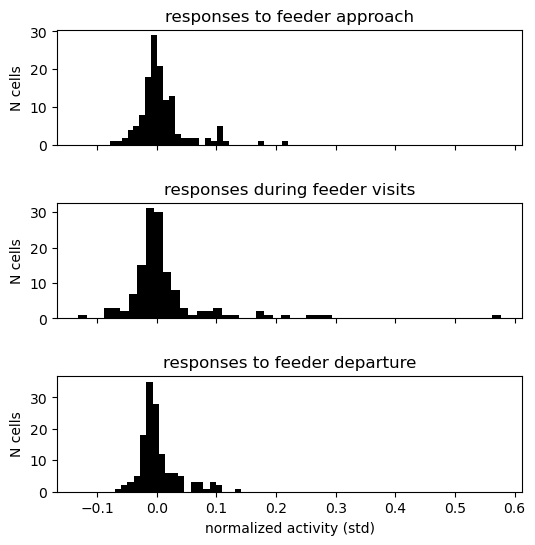

In [47]:
gs_kw = dict(hspace=0.5)
f, ax = plt.subplots(3, 1, figsize=(6, 6), sharex=True, gridspec_kw=gs_kw)

ax[0].hist(pre_response, color='k', bins=30)
ax[0].set_ylabel('N cells')
ax[0].set_title('responses to feeder approach')

ax[1].hist(during_response, color='k', bins=50)
ax[1].set_ylabel('N cells')
ax[1].set_title('responses during feeder visits')

ax[2].hist(post_response, color='k', bins=20)
ax[2].set_ylabel('N cells')
ax[2].set_xlabel('normalized activity (std)')
ax[2].set_title('responses to feeder departure')

plt.show()

In [38]:
''' get the proportions of feeder active cells '''
print(f'\nfeeder responsive cells for {bird}_{session_id}\n--------------------------------')

print('hand annotated feeder response proportions:')
these_feeder_cells = feeder_coding_dict[bird][session_id]
for key in these_feeder_cells.keys():
    n_feeder_cells = these_feeder_cells[key].shape[0]
    frac_feeder_cells = np.round(n_feeder_cells/n_cells*100, 2)
    print(f"{frac_feeder_cells}% had {key} feeder responses ({n_feeder_cells}/{n_cells})")


feeder responsive cells for IND67_251010
--------------------------------
hand annotated feeder response proportions:
11.94% had any feeder responses (16/134)
5.97% had up start feeder responses (8/134)
0.75% had up during feeder responses (1/134)
5.22% had up end feeder responses (7/134)
1.49% had suppressed feeder responses (2/134)


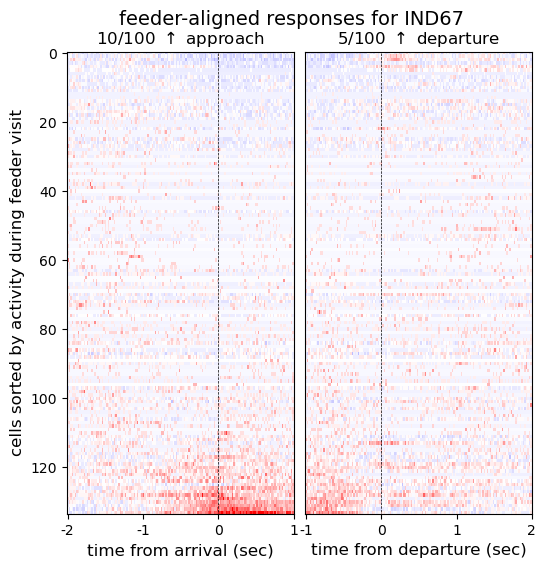

In [68]:
# plot responses relative to onset/offset
gs_kw = dict(wspace=0.05)
f, ax = plt.subplots(1, 2, figsize=(6, 6), gridspec_kw=gs_kw)
ax[0].imshow(avg_feeder_responses[sort_idx, :n_timepoints//2], clim=[-1, 1], 
             aspect='auto', cmap='bwr', interpolation='none')
ax[1].imshow(avg_feeder_responses[sort_idx, n_timepoints//2:], clim=[-1, 1], 
             aspect='auto', cmap='bwr', interpolation='none')
ylims = ax[0].get_ylim()

# plot arrival/departure
ax[0].vlines(t_pre, 0, n_cells, colors='k', linestyles='dashed', lw=0.5)
ax[1].vlines(t_end, 0, n_cells, colors='k', linestyles='dashed', lw=0.5)
ax[0].set_ylim(ylims)
ax[1].set_ylim(ylims)

# axis labels
ax[0].set_xlabel('time from arrival (sec)', fontsize=axis_label)
ax[1].set_xlabel('time from departure (sec)', fontsize=axis_label)
ax[0].set_ylabel('cells sorted by activity during feeder visit', fontsize=axis_label)
ax[1].set_yticks([])
ax[1].tick_params(labelleft=False)
ax[0].set_title(fr"10/100 $\uparrow$ approach", fontsize=axis_label)
ax[1].set_title(fr"5/100 $\uparrow$ departure", fontsize=axis_label)
f.suptitle(f'feeder-aligned responses for {bird}', y=0.95, fontsize=title_size)

# ticks
ax[0].set_xticks(np.arange(0, t_pre+t_begin+1/dt, 1/dt))
ax[1].set_xticks(np.arange(0, t_post+t_end+1/dt, 1/dt))
ax0_labels = (np.arange(-t_pre, t_begin+1/dt, 1/dt))*dt
ax1_labels = (np.arange(-t_end, t_post+1/dt, 1/dt))*dt
ax[0].set_xticklabels(ax0_labels.astype(int))
ax[1].set_xticklabels(ax1_labels.astype(int))

plt.show()
# f.savefig(f'{save_figs}/{bird}_{session_id}_feeder_tuning.png', dpi=400, bbox_inches='tight')

In [61]:
# font sizes
title_size = 14
axis_label = 12
tick_label = 10